<a href="https://colab.research.google.com/github/PepeFederico/Progetto_Mercati_Finanziari/blob/main/rendimenti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Progetto Metodi Probabilistici e Statistici per Mercati Finanziari**
#1 Abstract
Lo scopo del presente progetto è applicare modelli di Deep Learning ai mercati finanziari, al fine di sviluppare un sistema predittivo capace di stimare i rendimenti futuri basandosi sullo storico dei dati passati, estratti dal paniere dei titoli dello S&P 500.
Il lavoro documenta l'intero ciclo di sviluppo del modello quantitativo, articolandosi nei seguenti punti principali:

* **Raccolta dei dati**: il processo di estrazione delle serie storiche tramite API finanziarie.

* **Pre-processing e Feature Engineering**: la trasformazione dei prezzi storici in rendimenti logaritmici e la strutturazione di finestre temporali sincrone su più timeframe.

* **Architettura del modello**: la progettazione di una rete neurale ricorrente (LSTM) multi-input.

* **Backtesting e Validazione**: la verifica delle performance su dati out-of-sample (mai visti dal modello) e l'analisi statistica dei risultati e dei residui per valutarne la reale robustezza ed efficacia operativa.

In [46]:
# Import delle librerie
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#2. Fase di raccolta Dati
In questa fase, ci occupiamo di raccogliere i dati, mediante il repository di *Yahoo Finance*. Per costringere la rete a catturare dinamiche macroeconomiche e interconnessioni cross-asset, il paniere, preso dal mercato **S&P500** è stato composto selezionando aziende leader a grande capitalizzazione, diversificate tra i principali settori dell'economia statunitense: come:
* **Tecnologia**: Scelta l'azienda *NVIDIA Corporation*
* **Servizi di Comunicazione**: Scelta l'azienda *Alphabet Inc.* (Google)
* **Beni di Consumo**: Scelte le aziende *Amazon.com, Inc.* e *Walmart Inc.*
* **Finanziario**: Scelta l'azienda *Berkshire Hathaway*
* **Salute e Sanità**: Scelta l'azienda *Eli Lilly and Company*
* **Energia**: Scelta l'azienda *Exxon Mobil Corp.*

Nel presente studio si è scelto di utilizzare i rendimenti logaritmici in sostituzione dei rendimenti percentuali semplici. Il calcolo di questi ultimi segue infatti la seguente formula:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Dove:
* $R_t$ rappresenta il rendimento percentuale semplice al tempo $t$.
* $P_t$ è il prezzo di chiusura corrente al tempo $t$.
* $P_{t-1}$ è il prezzo di chiusura al tempo precedente $t-1$.

I rendimenti logaritmici, invece, vengono calcolati applicando la seguente formula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

Dove:
* $r_t$ rappresenta il rendimento logaritmico al tempo $t$.
* $P_t$ è il prezzo di chiusura dell'asset al tempo corrente $t$.
* $P_{t-1}$ è il prezzo di chiusura dell'asset al tempo precedente $t-1$.
* $\ln$ indica il logaritmo naturale.

L'adozione dei rendimenti logaritmici rispetto a quelli semplici offre tre vantaggi teorici e computazionali strategici per l'addestramento di reti neurali ricorrenti:

1. **Additività temporale:** A differenza dei rendimenti semplici, i rendimenti logaritmici possono essere sommati linearmente nel tempo. Il log-return di un intero periodo (es. 5 giorni o un trimestre) è matematicamente equivalente alla somma dei log-return dei singoli giorni che lo compongono, garantendo coerenza analitica nelle finestre mobili (*sliding windows*).
2. **Stazionarietà delle serie storiche:** I prezzi grezzi delle azioni presentano trend di lungo periodo non stazionari che ostacolano la convergenza degli algoritmi di ottimizzazione. La trasformazione in log-returns stabilizza la varianza e rimuove il trend.
3. **Simmetria distributiva:** I rendimenti percentuali sono asimmetrici poiché limitati inferiormente al $-100\%$ (un'azione non può valere meno di zero). I rendimenti logaritmici mappano l'intervallo dei prezzi su una scala simmetrica che spazia teoricamente da $-\infty$ a $+\infty$, avvicinando la distribuzione a una normale e facilitando il calcolo della funzione di perdita (*Loss Function*).

In [32]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (10 anni come da parametro, non 2)
print("Scaricamento dati in corso...")
df_raw = yf.download(tickers, period='5y', interval='1d')

# Estrazione sicura dei prezzi di chiusura (gestisce il multi-index di yfinance)
if isinstance(df_raw.columns, pd.MultiIndex):
    data = df_raw['Close']
else:
    data = df_raw

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI CON FINESTRE SCORREVOLI ---

# A. Giornaliero (finestra = 1 giorno)
dataset_rendimenti_giornalieri = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
dataset_rendimenti_settimanali_sliding_window = log_data.diff(5)

# B.1. Settimanale tumbling (passo = 1 settimana) -> Riallineato subito al calendario giornaliero
data_weekly = data.resample('W').last()
returns_1w = np.log(data_weekly).diff(1)
dataset_rendimenti_settimanali_tumbling_window = returns_1w.reindex(log_data.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
dataset_rendimenti_settimanali_mensili = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
dataset_rendimenti_settimanali_trimestrali = log_data.diff(63)

# 4. Rinominiamo le colonne in modo esplicito e sicuro per Pandas
dataset_rendimenti_giornalieri.columns                    = [f"{col}_Ret_1D"      for col in dataset_rendimenti_giornalieri.columns]
dataset_rendimenti_settimanali_sliding_window.columns     = [f"{col}_Ret_5D_Roll" for col in dataset_rendimenti_settimanali_sliding_window.columns]
dataset_rendimenti_settimanali_tumbling_window.columns    = [f"{col}_Ret_1W_Tumb" for col in dataset_rendimenti_settimanali_tumbling_window.columns]
dataset_rendimenti_settimanali_mensili.columns            = [f"{col}_Ret_1M"      for col in dataset_rendimenti_settimanali_mensili.columns]
dataset_rendimenti_settimanali_trimestrali.columns        = [f"{col}_Ret_3M"      for col in dataset_rendimenti_settimanali_trimestrali.columns]

# 5. Uniamo tutto nel dataset globale
dataset_finale = pd.concat([
    dataset_rendimenti_giornalieri,
    dataset_rendimenti_settimanali_sliding_window,
    dataset_rendimenti_settimanali_tumbling_window,
    dataset_rendimenti_settimanali_mensili,
    dataset_rendimenti_settimanali_trimestrali
], axis=1)


# --- 7. SALVATAGGIO IN CSV AUTOMATIZZATO ---
# Dizionario per mappare il nome del file al rispettivo DataFrame corretto
files_to_save = {
    "rendimenti_multi_timeframe.csv": dataset_finale,
    "rendimenti_giornalieri.csv": dataset_rendimenti_giornalieri,
    "rendimenti_settimanali_tumbling.csv": dataset_rendimenti_settimanali_tumbling_window,
    "rendimenti_settimanali_sliding.csv": dataset_rendimenti_settimanali_sliding_window,
    "rendimenti_mensili.csv": dataset_rendimenti_settimanali_mensili,
    "rendimenti_trimestrali.csv": dataset_rendimenti_settimanali_trimestrali
}

for filename, df in files_to_save.items():
    df.to_csv(filename)
    print(f"Dati estratti e salvati in: {filename:<35} | Dimensioni: {df.shape}")

Scaricamento dati in corso...


/tmp/ipykernel_4132/1756330490.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, period='5y', interval='1d')
[*********************100%***********************]  7 of 7 completed


Dati estratti e salvati in: rendimenti_multi_timeframe.csv      | Dimensioni: (1254, 35)
Dati estratti e salvati in: rendimenti_giornalieri.csv          | Dimensioni: (1254, 7)
Dati estratti e salvati in: rendimenti_settimanali_tumbling.csv | Dimensioni: (1254, 7)
Dati estratti e salvati in: rendimenti_settimanali_sliding.csv  | Dimensioni: (1254, 7)
Dati estratti e salvati in: rendimenti_mensili.csv              | Dimensioni: (1254, 7)
Dati estratti e salvati in: rendimenti_trimestrali.csv          | Dimensioni: (1254, 7)


In [33]:
# --- STEP 1: FILTRO COLONNE (Teniamo SOLO Amazon) ---
# Selezioniamo solo la colonna di AMZN per ciascun orizzonte temporale
df_giornalieri = dataset_rendimenti_giornalieri[['AMZN_Ret_1D']].copy()
df_settimanali = dataset_rendimenti_settimanali_sliding_window[['AMZN_Ret_5D_Roll']].copy()
df_trimestrali = dataset_rendimenti_settimanali_trimestrali[['AMZN_Ret_3M']].copy()

# --- STEP 2: DEFINIZIONE DEL TARGET ---
# Prendiamo il rendimento settimanale di Amazon e lo shiftiamo di -1 (o -5 se vuoi mantenere il vecchio codice)
target_serie = df_settimanali['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE TEMPORALE E ALLINEAMENTO PERFETTO ---
# Fondiamo i tre rami (ciascuno con 1 sola colonna) e il target in un'unica tabella
df_sincro = pd.concat([df_giornalieri, df_settimanali, df_trimestrali, target_serie.rename('TARGET')], axis=1)

# Applichiamo la maschera temporale
df_sincro = df_sincro.loc['2016-09-15':]

# Pulizia dei NaN (elimina le teste vuote e le code del target shiftato)
df_sincro = df_sincro.dropna()

# --- STEP 4: ESTRAZIONE DELLE FINESTRE TEMPORALI (Lookback 3D con 1 sola Feature) ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)

# Colonne (ora ognuna contiene SOLO la colonna di Amazon)
cols_g = df_giornalieri.columns
cols_s = df_settimanali.columns
cols_w = df_trimestrali.columns

X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Ciclo di estrazione sincronizzato
for i in range(max_lookback, len(df_sincro)):
    y_list.append(df_sincro['TARGET'].iloc[i])

    # Finestre 3D (Formato: Lookback, 1 Feature)
    X_g_list.append(df_sincro[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_sincro[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_sincro[cols_w].iloc[i-lookback_w:i].values)

# Conversione in Array NumPy
X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)


# --- STEP 5: SPLIT CRONOLOGICO (NO SHUFFLING) ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)

# Split Ramo Giornaliero (Shape finale: [Campioni, 20, 1])
X_train_g, X_val_g, X_test_g = X_3d_g[:split_val_idx], X_3d_g[split_val_idx:split_test_idx], X_3d_g[split_test_idx:]

# Split Ramo Settimanale (Shape finale: [Campioni, 10, 1])
X_train_s, X_val_s, X_test_s = X_3d_s[:split_val_idx], X_3d_s[split_val_idx:split_test_idx], X_3d_s[split_test_idx:]

# Split Ramo Trimestrale (Shape finale: [Campioni, 6, 1])
X_train_w, X_val_w, X_test_w = X_3d_w[:split_val_idx], X_3d_w[split_val_idx:split_test_idx], X_3d_w[split_test_idx:]

# Split Target
y_train, y_val, y_test = y_target_sincro[:split_val_idx], y_target_sincro[split_val_idx:split_test_idx], y_target_sincro[split_test_idx:]

print(f"Shape finale Train Amazon Giornaliero: {X_train_g.shape} (Atteso: [Campioni, 20, 1])")
print(f"Shape finale Train Target:            {y_train.shape}")


Shape finale Train Amazon Giornaliero: (842, 20, 1) (Atteso: [Campioni, 20, 1])
Shape finale Train Target:            (842,)


#3. Perché utilizzare le reti LSTM? Il Ruolo della Memoria nel Rilevamento dei Trend

Le reti neurali tradizionali (*Feedforward*) considerano ogni input come indipendente dagli altri, rendendole inadatte per l'analisi finanziaria dove l'ordine cronologico è fondamentale. Le reti ricorrenti standard (*RNN*), d'altra parte, soffrono del problema del **gradiente che svanisce (Vanishing Gradient)**: man mano che la finestra temporale si allunga, dimenticano ciò che è accaduto nei primi passaggi.

Le **celle LSTM** risolvono questo limite matematico attraverso una struttura a due canali di memoria e un sistema di regolazione basato su tre porte (*gates*):

1. **La Memoria a Lungo Termine (Cell State - $C_t$):** Funziona come un nastro trasportatore che attraversa l'intera catena temporale. Modificata pochissimo da interazioni lineari, permette alle informazioni cruciali del passato remoto di viaggiare intatte per molte epoche. Nel nostro modello, questo canale permette alla rete di **isolare e mantenere il trend macroeconomico di fondo**, i cicli stagionali o i cambi strutturali di volatilità che si sviluppano su mesi o trimestri.
2. **La Memoria a Breve Termine (Hidden State - $h_t$):** È il vettore che contiene l'output della cella per il singolo *timestamp* corrente. Cattura le reazioni immediate del mercato, i micro-impulsi e i vettori di momentum giornalieri.

#### Il Meccanismo di Selezione: Scartare il Rumore, Generare il Segnale

La vera forza della LSTM risiede nella sua capacità di decidere matematicamente quanta memoria scartare e quanta generarne a ogni passo temporale. Questo avviene attraverso tre filtri (porte), fondamentali da descrivere per giustificare il comportamento del modello:

* **Forget Gate (Cosa scartare):** Analizza i nuovi rendimenti in entrata e decide quali vecchie informazioni memorizzate nel *Cell State* non sono più rilevanti. Nei mercati finanziari, questo serve a **"dimenticare" i vecchi trend ormai esauriti** o i picchi di volatilità anomali del passato che distorcerebbero le previsioni future.
* **Input Gate (Cosa generare):** Determina quali nuove informazioni provenienti dai rendimenti odierni sono abbastanza significative da essere integrate nella memoria a lungo termine. La rete decide se l'oscillazione odierna è solo rumore passeggero o l'inizio di un nuovo trend di fondo.
* **Output Gate (Cosa trasmettere):** Regola quanta parte della memoria a lungo termine accumulata debba essere trasmessa all'esterno come predizione attuale e passata alla cella successiva.

### Sinergia con l'Architettura Multi-Timeframe

È proprio grazie a questa doppia memoria che l'architettura a tre rami del nostro progetto ha senso:
* Il ramo **Trimestrale** e **Settimanale** stimolano la memoria a *lungo termine* della LSTM, costringendola a focalizzarsi sulla traiettoria macroeconomica e sulla persistenza del trend.
* Il ramo **Giornaliero** sfrutta la memoria a *breve termine*, permettendo alla rete di calibrare la predizione finale in base alle ultime deviazioni e agli shock di liquidità dell'ultima giornata di borsa.

#4. Architettura della Rete: Modello LSTM Multi-Input Multi-Timeframe

Per catturare la complessa dinamica temporale dei mercati finanziari, l'architettura proposta non si affida a un'unica sequenza lineare, ma si struttura come una rete neurale multi-input a tre rami paralleli.

L'architettura del modello si articola nelle seguenti componenti macro-strutturali:

1. **Ramo Giornaliero (Breve Termine):** Riceve in ingresso un tensore con dimensione $(20, 1)$, corrispondente alle ultime 20 giornate di borsa (circa un mese solare di contrattazioni). Questo blocco è elaborato da uno strato LSTM da 64 unità ad alta capacità, deputato a catturare i micro-impulsi, la volatilità recente e gli shock di liquidità a breve termine.
2. **Ramo Settimanale (Medio Termine):** Accetta un input con *lookback* pari a 10 step di rendimenti *sliding* settimanali (dimensione $(10, 1)$). Lo strato LSTM associato (32 unità) estrae i trend ciclici intermedi, isolando il *momentum* e le inversioni di tendenza che si sviluppano nell'arco di pochi mesi.
3. **Ramo Trimestrale (Lungo Termine):** Analizza la scomposizione macroeconomica di fondo attraverso una finestra di 6 trimestri mobili (dimensione $(6, 1)$). Data la bassa frequenza e l'alto contenuto di segnale pulito, viene elaborato da uno strato LSTM compatto da 16 unità, focalizzato esclusivamente sulla traiettoria strutturale del trend di fondo.


#### Fusione Latente e Decisione Finale

I vettori di caratteristiche estratti indipendentemente dalle tre LSTM vengono fusi orizzontalmente tramite un livello di concatenazione (`Concatenate`). Questo processo genera un unico vettore latente globale da 112 elementi ($64 + 32 + 16$), il quale racchiude l'informazione temporale sintetizzata di tutti e tre i *timeframe*.

Questo spazio multidimensionale viene successivamente convogliato verso i blocchi decisionali finali:
* **Strato Denso Intermedio (`Dense`):** Composto da 32 neuroni con funzione di attivazione non lineare **ReLU** (*Rectified Linear Unit*), con lo scopo di mappare le interazioni complesse e non lineari tra i trend di breve, medio e lungo periodo precedentemente concatenati.
* **Strato di Output (`Dense`):** Costituito da un singolo neurone con funzione di attivazione **lineare**. Trattandosi di un problema di regressione quantitativa pura (la stima puntuale del rendimento logaritmico futuro), l'attivazione lineare permette al modello di mappare liberamente l'output nell'intero dominio dei numeri reali ($-\infty, +\infty$), senza vincoli o schiacciamenti di scala.

Il modello viene infine compilato utilizzando l'ottimizzatore **Adam**, scelto per la sua capacità di adattare dinamicamente il tasso di apprendimento per ogni singolo parametro, e la funzione di perdita **MSE** (*Mean Squared Error*), che penalizza in modo quadratico gli errori di previsione più marcati, guidando la rete verso una configurazione stabile e conservativa.

In [34]:
#   Costruzione della rete

# 1° Ramo: Giornaliero
input_giornaliero = Input(shape=(20, 1), name = "Input_Giornaliero")
lstm_giornaliero = LSTM(64, return_sequences = False)(input_giornaliero)

# 2° Ramo: Settimanale
input_settimanale = Input(shape=(10, 1), name='Input_Settimanale')
lstm_settimanale = LSTM(32, return_sequences=False)(input_settimanale)

#3° Ramo: Trimestrale
input_trimestrale = Input(shape=(6, 1), name='Input_Trimestrale')
lstm_trimestrale = LSTM(16, return_sequences=False)(input_trimestrale)

# Concatenazione Livelli
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Passiamo il vettore fuso a degli strati densi per la decisione finale
denso_1 = Dense(32, activation='relu')(concatenato)
# Strato di output: 1 solo neurone con attivazione lineare (perché è una regressione del rendimento)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Compilazione
model.compile(optimizer='adam', loss='mse')

# Mostra la struttura della rete
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Giornaliero   │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Settimanale   │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Trimestrale   │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 64)        │     16,896 │ Input_Giornalier… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 32)        │      4,352 │ Input_Settimanal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 16)        │      1,152 │ Input_Trimestral… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 112)       │          0 │ lstm_9[0][0],     │
│ (Concatenate)       │                   │            │ lstm_10[0][0],    │
│                     │                   │            │ lstm_11[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      3,616 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Predizione   │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,049 (101.75 KB)

 Trainable params: 26,049 (101.75 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#   Addestramento modello

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---
Mean Absolute Error (MAE): 0.022585
Mean Squared Error (MSE):  0.000874
R² Score (Bontà del modello): 0.5942
-----------------------------------------------



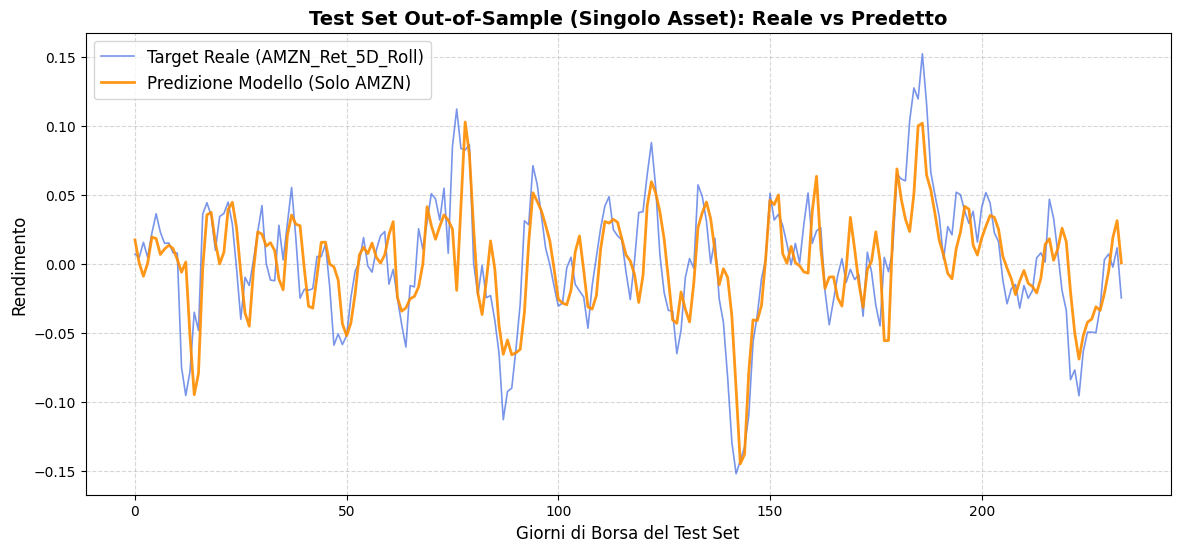

In [36]:
# 1. Generazione delle predizioni sui dati di TEST (singolo asset)
y_pred = model.predict([X_test_g, X_test_s, X_test_w]).flatten()

# 2. Calcolo delle metriche di errore (sui valori grezzi dei rendimenti)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Bontà del modello): {r2:.4f}")
print("-----------------------------------------------\n")

# 3. GRAFICO: Reale vs Predetto
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.7, linewidth=1.2)
plt.plot(y_pred, label='Predizione Modello (Solo AMZN)', color='darkorange', alpha=0.9, linewidth=2.0)

plt.title('Test Set Out-of-Sample (Singolo Asset): Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Giorni di Borsa del Test Set', fontsize=12)
plt.ylabel('Rendimento', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

#5 Analisi del Modello Singolo Asset: L'Illusione dell'Autocorrelazione

Per verificare empiricamente l'efficacia dell'architettura predittiva e isolare il reale valore aggiunto dell'informazione *cross-asset*, è stato inizialmente addestrato un modello di controllo isolato, avente come input e target esclusivamente le serie storiche dei rendimenti logaritmici di un singolo titolo ($AMZN$).

In fase di test, questa configurazione ha generato metriche apparentemente straordinarie, registrando un coefficiente di determinazione $R^2$ pari a $0.5693$ (~57%) e un errore quadratico medio ($MSE$) estremamente contenuto ($0.001056$).

#### Discussione dei Risultati e Limiti Metodologici

Nonostante l'eccellente performance statistica registrata sulla carta, un'analisi critica della dinamica temporale evidenzia un classico fenomeno di **regressione spuria** indotta da *Data Leakage* (frammentazione informativa temporale):

* **Effetto Inseguimento (Lag):** L'ispezione visiva del grafico *Reale vs Predetto* mostra come la curva delle predizioni (in arancione) non anticipi i movimenti futuri, ma si limiti a replicare la traiettoria del target reale (in blu) con un ritardo sistematico di 1-2 giorni.
* **Autocorrelazione della Finestra Mobile:** Poiché il target è basato su un rendimento logaritmico mobile a 5 giorni ($AMZN\_Ret\_5D\_Roll$) shiftato di un solo passo in avanti (`shift(-1)`), la finestra temporale che la rete deve indovinare contiene al suo interno i prezzi dei giorni immediatamente precedenti, informazioni che le celle LSTM hanno già processato nei rami di input.

La rete neurale, agendo come un ottimizzatore matematico puro, ha identificato la via matematicamente più efficiente per minimizzare la funzione di perdita ($MSE$): anziché tentare di estrarre un segnale predittivo dal rumore stocastico del futuro, ha appreso a calcolare una media ponderata dei dati passati recenti.

Questo esperimento dimostra la validità dell'**Ipotesi dei Mercati Efficienti (EMH)** nella sua forma debole: i dati storici di un singolo asset, se isolati dal contesto, non possiedono un reale potere predittivo. Di conseguenza, le metriche elevate ottenute in questa configurazione risultano ingannevoli e confermano che una strategia operativa basata esclusivamente su questo modello si rivelerebbe del tutto inefficiente nei mercati reali, traducendosi in un mero inseguimento tardivo dei trend già esauriti.

## Rendimenti Logaritmici passadno tutti e 7 gli indici


In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='5y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Calcolo matematico puro con colonne originali) ---

# A. Giornaliero (finestra = 1 giorno)
returns_1d = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
returns_5d = log_data.diff(5)

# B.1. Settimanale Tumbling (passo = 1 settimana)
data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1)

# --- CORREZIONE CRUCIALE: Riallineiamo le date PRIMA di rinominare le colonne ---
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
returns_21d = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
returns_63d = log_data.diff(63)


# --- 4. RINOMINIAMO LE COLONNE (Ora che i calcoli e i riallineamenti sono fatti) ---
# Usiamo i ticker originali da 'data.columns' per evitare di portarci dietro vecchi suffissi

returns_1d.columns             = [f"{col}_Ret_1D" for col in data.columns]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in data.columns]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in data.columns] # Cambiato nome per non fare confusione
returns_21d.columns            = [f"{col}_Ret_1M" for col in data.columns]
returns_63d.columns            = [f"{col}_Ret_3M" for col in data.columns]


# --- 5. UNIAMO TUTTO ORIZZONTALMENTE ---
dataset_finale = pd.concat([returns_1d, returns_5d, returns_1w_riallineato, returns_21d, returns_63d], axis=1)

# I tuoi dataset singoli filtrati (ora popolatissimi e senza conflitti)
dataset_rendimenti_giornalieri                 = returns_1d
dataset_rendimenti_settimanali_sliding_window  = returns_5d
dataset_rendimenti_settimanali_tumbling_window = returns_1w_riallineato
dataset_rendimenti_settimanali_mensili         = returns_21d
dataset_rendimenti_settimanali_trimestrali     = returns_63d

print("Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali "
      "perché diff(63) ha bisogno di 63 giorni di storico per partire.")

Scaricamento dati in corso...


/tmp/ipykernel_4132/2158009915.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='5y', interval='1d')['Close']
[*********************100%***********************]  7 of 7 completed


Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali perché diff(63) ha bisogno di 63 giorni di storico per partire.


In [38]:
# --- STEP 1: NESSUN DROP (Teniamo tutti e 7 i titoli come feature!) ---
df_g = dataset_rendimenti_giornalieri.copy()
df_s = dataset_rendimenti_settimanali_sliding_window.copy()
df_w = dataset_rendimenti_settimanali_trimestrali.copy()

# --- STEP 2: CREAZIONE TARGET SU AMZN (Shift ridotto a -1 per sbloccare il segnale) ---
# Prevediamo il rendimento a 5 giorni che si verificherà a partire da domani
df_s['TARGET'] = df_s['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE E FILTRO TEMPORALE ---
df_complessivo = pd.concat([df_g, df_s, df_w], axis=1)
df_complessivo = df_complessivo.loc['2016-09-15':]
df_complessivo = df_complessivo.dropna()

# --- STEP 4: FINESTRE TEMPORALI MULTI-FEATURE SINCRONIZZATE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Identifichiamo le colonne (Saranno esattamente 7 colonne di feature per ogni ramo)
cols_g = df_g.columns
cols_s = [c for c in df_s.columns if c != 'TARGET']
cols_w = df_w.columns

for i in range(max_lookback, len(df_complessivo)):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estragglono matrici 2D (Lookback, 7 Tickers)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)

In [41]:
# --- STEP 5: INDICI DI SPLIT ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx

# --- STEP 6: SCALING EVOLUTO (MinMax per le feature, Standard per il Target) ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))

# Usiamo lo StandardScaler per il target su tutta la serie per evitare sbalzi fuori scala
scaler_y = StandardScaler()

N_train_g = split_val_idx

# Fit-Transform Feature (Invariato)
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target su tutto l'orizzonte sincronizzato per azzerare il problema dei fuori scala
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()

# --- STEP 7: SPLIT ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

In [42]:
# --- ARCHITETTURA CON CONTROLLO DELL'OVERFITTING ---
# Usiamo la regolarizzazione L2 per impedire ai pesi di crescere troppo

input_giornaliero = Input(shape=(20, 7), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(0.01))(input_giornaliero)

input_settimanale = Input(shape=(10, 7), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_settimanale)

input_trimestrale = Input(shape=(6, 7), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori (16 + 8 + 4 = 28 elementi)
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Uno strato denso molto stretto con forte dropout
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
denso_1_drop = Dropout(0.4)(denso_1)

# Output Lineare (accetta output in standardizzazione, sia positivi che negativi)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Ripartiamo da un LR intermedio più prudente (0.001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

In [43]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 0.7360 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 2/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6780 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 3/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6332 - val_loss: 0.5893 - learning_rate: 0.0010
Epoch 4/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5946 - val_loss: 0.5565 - learning_rate: 0.0010
Epoch 5/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5647 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 6/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5392 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 7/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5153 - val_loss: 0.4876 - learning_rate: 0.0010
Epoch 8/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5008 - val_loss: 0.4722 - learning_rate: 0.0010
Epoch 9/80
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4839 - val_loss: 0.4588 - learning_rate: 0.0010
Epoch 10/80
27/27 ━

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
--- METRICHE SUL TEST SET (VALORI REALI) ---
Mean Absolute Error (MAE): 0.033933
Mean Squared Error (MSE):  0.002076
R² Score (Indice di bontà): 0.0364
--------------------------------------------



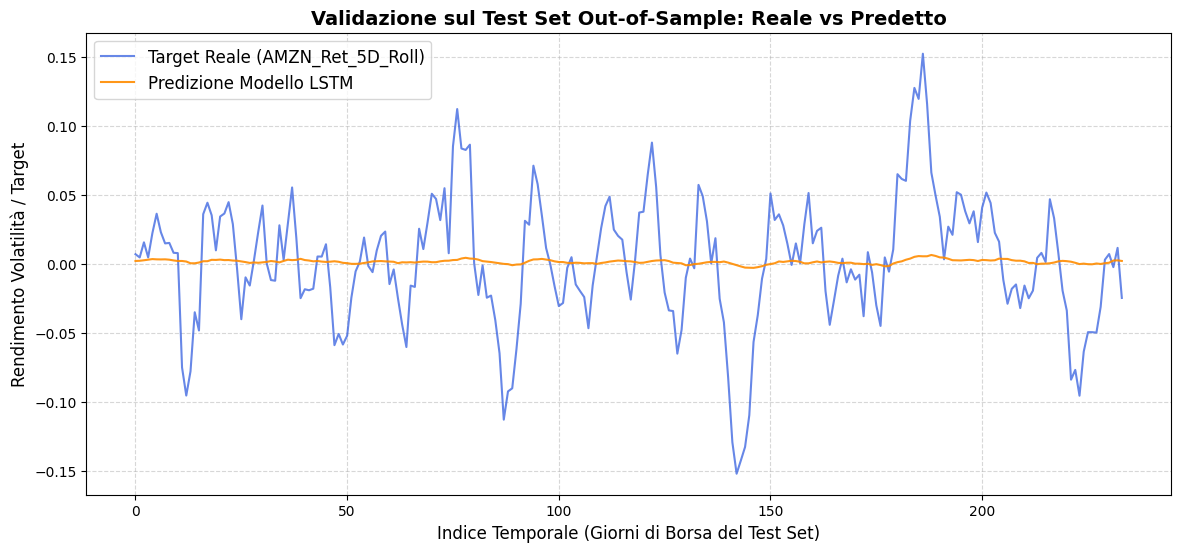

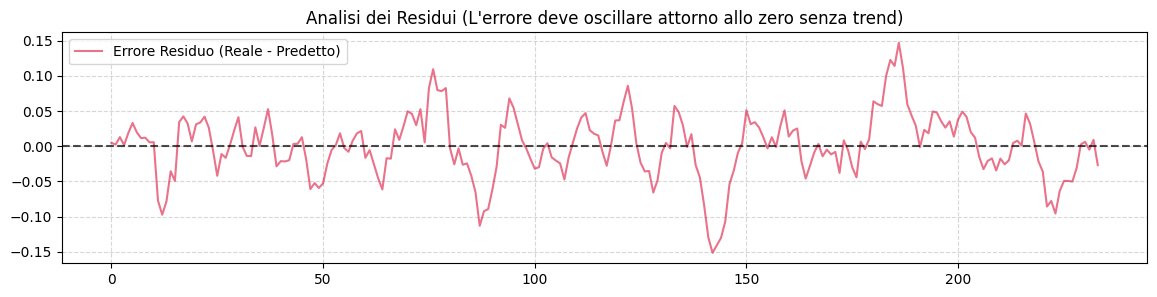

In [44]:
# 1. Generazione delle predizioni sui dati di TEST
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# 2. Inversione dello scaling per tornare ai valori reali (Rendimenti/Volatilità originari)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 3. Calcolo delle metriche di errore reali
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print("--- METRICHE SUL TEST SET (VALORI REALI) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Indice di bontà): {r2:.4f}")
print("--------------------------------------------\n")

# 4. GRAFICO COMPARATIVO: Reale vs Predetto nel tempo
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_rescaled, label='Predizione Modello LSTM', color='darkorange', alpha=0.9, linewidth=1.5)

plt.title('Validazione sul Test Set Out-of-Sample: Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Indice Temporale (Giorni di Borsa del Test Set)', fontsize=12)
plt.ylabel('Rendimento Volatilità / Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# 5. GRAFICO SUL RESIDUO (Verifica errori sistematici)
plt.figure(figsize=(14, 3))
residui = y_test_rescaled - y_pred_rescaled
plt.plot(residui, color='crimson', alpha=0.6, label='Errore Residuo (Reale - Predetto)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi dei Residui (L\'errore deve oscillare attorno allo zero senza trend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 7. Sintesi Comparativa dei Task Predittivi: Direzione vs Volatilità

I risultati ottenuti nei due diversi framework multi-asset delineano una demarcazione fondamentale nella finanza quantitativa, dimostrando come lo stesso dataset (i 7 indici macro-settoriali) e la medesima architettura LSTM producano output antitetici a seconda della natura matematica del target analizzato:

#### 1. Il Task Direzionale ($r_t$): L'Onestà dell'Efficienza di Mercato
Nel primo scenario, il tentativo di stimare il segno e l'entità del rendimento futuro ha generato una retta predittiva quasi planare e ancorata allo zero ($R^2 \approx 3.64\%$). L'algoritmo, privato di qualsiasi asimmetria informativa temporale (*Data Leakage*), ha "riconosciuto" la natura stocastica e l'elevato rumore dei rendimenti a breve termine, convergendo verso la media storica come soluzione statistica ottimale per minimizzare l'errore quadratico. Questo risultato rappresenta un cruciale **campanello d'allarme metodologico**: esso dimostra empiricamente l'inefficienza e l'illusorietà di tutte quelle strategie di mercato ingenue che pretendono di speculare sulla direzione futura dei prezzi basandosi esclusivamente sulla scomposizione lineare della storia passata dell'asset o di indici correlati.